# CÓDIGO FINAL

### Declaración sobre el uso de herramientas de inteligencia artificial

Durante el desarrollo del código y la elaboración de algunos fragmentos técnicos de este trabajo se utilizaron herramientas basadas en inteligencia artificial como apoyo auxiliar para tareas de programación, depuración y mejora de la documentación. El uso de estas herramientas se limitó a funciones de asistencia y consulta, siendo la implementación final, validación de resultados, interpretación física y supervisión del contenido realizadas de forma íntegra por la autora del trabajo.

### Librerías a importar.

In [51]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

import math
from math import factorial, pi
from scipy.special import eval_hermite
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import minimize


from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

### Definimos las funciones.

In [52]:
def ladder_operators(N: int):
    r"""
    Construye matrices NxN de a y a^\dagger en la base |n>, n=0..N-1.
    """

    a = np.zeros((N, N), dtype=complex)
    adag = np.zeros((N, N), dtype=complex)
    
    for n in range(1, N):
        a[n-1, n] = np.sqrt(n)          # <n-1|a|n> = sqrt(n)
        adag[n, n-1] = np.sqrt(n)       # <n|a^\dagger|n-1> = sqrt(n)
    return a, adag

In [53]:
def ho_operators(N: int, m: float, w: float, hbar: float = 1.0):
    r"""
    Construye x y p como matrices NxN usando:
      x = sqrt(hbar/(2 m w)) (a + a^\dagger)
      p = i sqrt(m hbar w / 2) (a^\dagger - a)
    """

    a, adag = ladder_operators(N)
    x = np.sqrt(hbar/(2*m*w)) * (a + adag)
    p = 1j * np.sqrt(m*hbar*w/2) * (adag - a)
    return x, p, a, adag

In [54]:
def hamiltonian_ho(N: int, m: float, w: float, hbar: float = 1.0):
    x, p, _, _ = ho_operators(N, m, w, hbar)

    p2 = p @ p
    x2 = x @ x
    H0 = p2/(2*m) + 0.5*m*(w**2)*x2

    H0 = 0.5*(H0 + H0.conj().T)
    return H0

In [55]:
def hamiltonian_gup_ho(N: int, m: float, w: float, beta: float, hbar: float = 1.0):
    x, p, _, _ = ho_operators(N, m, w, hbar)

    p2 = p @ p
    x2 = x @ x
    H0 = p2/(2*m) + 0.5*m*(w**2)*x2

    p4 = p2 @ p2
    H1 = (beta/m) * p4

    H_g = H0 + H1
    H_g = 0.5*(H_g + H_g.conj().T)
    return H_g, H0, H1

In [56]:
def perturbative_shift(n: int, m: float, w: float, beta: float, hbar: float = 1.0):
    """
    ΔE_n^(1) = (beta/m) <n|p^4|n>
    con <n|p^4|n> = (3/4)(m hbar w)^2 (2n^2 + 2n + 1)
    """
    return (3/4) * beta * m * (hbar**2) * (w**2) * (2*n**2 + 2*n + 1)

In [57]:
def exact_energy_ho(n: int, w: float, hbar: float = 1.0):
    return hbar*w*(n + 0.5)

In [58]:
# Parámetros físicos
hbar = 1.0
m = 1.0
w = 1.0
N = 80
n_levels = 10

# Valores de beta
betas_p = np.array([0.0, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1], dtype=float)
betas_g = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5], dtype=float)

In [59]:
H0 = hamiltonian_ho(N, m, w, hbar)
evals0, evecs0 = np.linalg.eigh(H0)

print("Autovalores HO (referencia):")
print(evals0[:n_levels])
print("\n" + "="*50)

for beta in betas_p:
    H_g, _, H1 = hamiltonian_gup_ho(N, m, w, beta, hbar)
    evals_g, evecs_g = np.linalg.eigh(H_g)

    deltaE_num = evals_g[:n_levels] - evals0[:n_levels]
    deltaE_pert = np.array([perturbative_shift(n, m, w, beta, hbar) for n in range(n_levels)])
    diff = deltaE_num - deltaE_pert

    print(f"\nBeta = {beta}")
    print("Autovalores GUP:")
    print(evals_g[:n_levels])
    print("Corrección (GUP - HO):")
    print(deltaE_num)
    print("Corrección perturbativa:")
    print(deltaE_pert)
    print("Diferencia numérica - perturbativa:")
    print(diff)

for beta in betas_g:
    H_g, _, H1 = hamiltonian_gup_ho(N, m, w, beta, hbar)
    evals_g, evecs_g = np.linalg.eigh(H_g)

    deltaE_num = evals_g[:n_levels] - evals0[:n_levels]
    deltaE_pert = np.array([perturbative_shift(n, m, w, beta, hbar) for n in range(n_levels)])
    diff = deltaE_num - deltaE_pert

    print(f"\nBeta = {beta}")
    print("Autovalores GUP:")
    print(evals_g[:n_levels])
    print("Corrección (GUP - HO):")
    print(deltaE_num)
    print("Corrección perturbativa:")
    print(deltaE_pert)
    print("Diferencia numérica - perturbativa:")
    print(diff)

Autovalores HO (referencia):
[0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5]


Beta = 0.0
Autovalores GUP:
[0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5]
Corrección (GUP - HO):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Corrección perturbativa:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Diferencia numérica - perturbativa:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Beta = 0.0001
Autovalores GUP:
[0.50007497 1.50037479 2.50097423 3.50187304 4.50307095 5.50456772
 6.5063631  7.50845683 8.51084867 9.51353836]
Corrección (GUP - HO):
[7.49737708e-05 3.74793994e-04 9.74232502e-04 1.87303541e-03
 3.07094941e-03 4.56772172e-03 6.36310014e-03 8.45683299e-03
 1.08486692e-02 1.35383581e-02]
Corrección perturbativa:
[7.5000e-05 3.7500e-04 9.7500e-04 1.8750e-03 3.0750e-03 4.5750e-03
 6.3750e-03 8.4750e-03 1.0875e-02 1.3575e-02]
Diferencia numérica - perturbativa:
[-2.62292115e-08 -2.06005719e-07 -7.67497849e-07 -1.96458524e-06
 -4.05059009e-06 -7.27827891e-06 -1.18998647e-05 -1.81670089e-05
 -2.63308232e-05 -3.66418715e-05]

Beta = 0.0005
Au

# BETAS PEQUEÑAS.

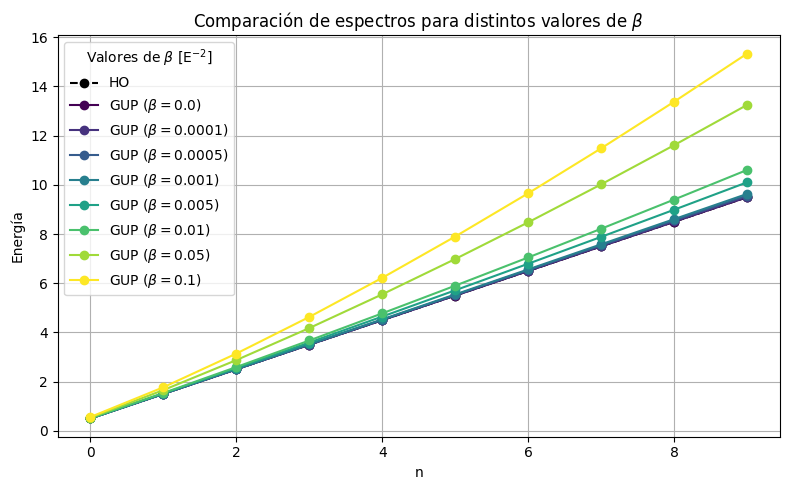

In [60]:
# Eje x discreto: n = 0, 1, 2, ..., n_levels-1
n_vals = np.arange(n_levels)

# Ajustar n_levels automáticamente
n_levels = len(n_vals)

plt.figure(figsize=(8, 5))

# HO como referencia
plt.plot(n_vals, evals0[:n_levels],
         'o--',
         color='black',
         label='HO')

# Colores viridis
colors = plt.cm.viridis(np.linspace(0, 1, len(betas_p)))

for beta_plot, c in zip(betas_p, colors):
    H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)
    evals_g, _ = np.linalg.eigh(H_g)

    plt.plot(n_vals, evals_g[:n_levels],
             marker='o',
             linestyle='-',
             color=c,
             label=fr'GUP ($\beta={beta_plot}$)')

plt.xlabel('n')
plt.ylabel('Energía')
plt.title('Comparación de espectros para distintos valores de $\\beta$')

plt.legend(title=r'Valores de $\beta$ [E$^{-2}$]')
plt.grid()
plt.tight_layout()

plt.show()

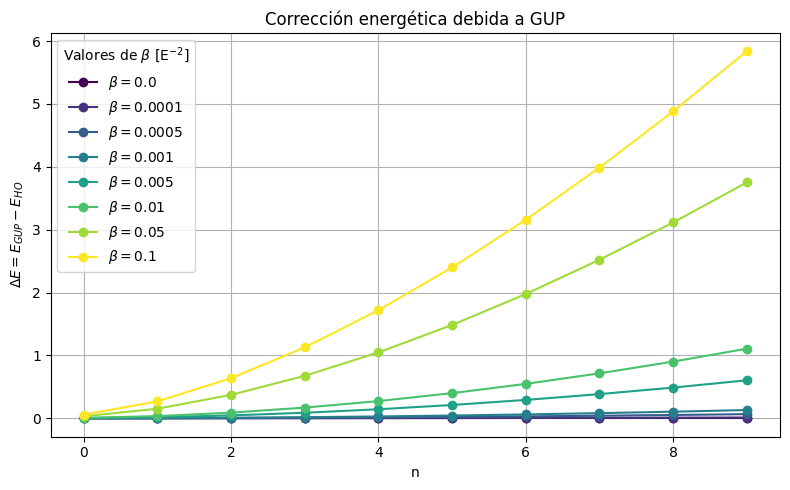

In [61]:
plt.figure(figsize=(8, 5))

# Colores tipo viridis
colors = plt.cm.viridis(np.linspace(0, 1, len(betas_p)))

for beta_plot, c in zip(betas_p, colors):
    H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)
    evals_g, _ = np.linalg.eigh(H_g)

    deltaE = evals_g[:n_levels] - evals0[:n_levels]

    plt.plot(n_vals, deltaE,
             marker='o',
             linestyle='-',
             color=c,
             label=fr'$\beta={beta_plot}$')

plt.xlabel('n')
plt.ylabel(r'$\Delta E = E_{GUP} - E_{HO}$')
plt.title('Corrección energética debida a GUP')

plt.legend(title=r'Valores de $\beta$ [E$^{-2}$]')
plt.grid()
plt.tight_layout()

plt.show()

## BETAS GRANDES

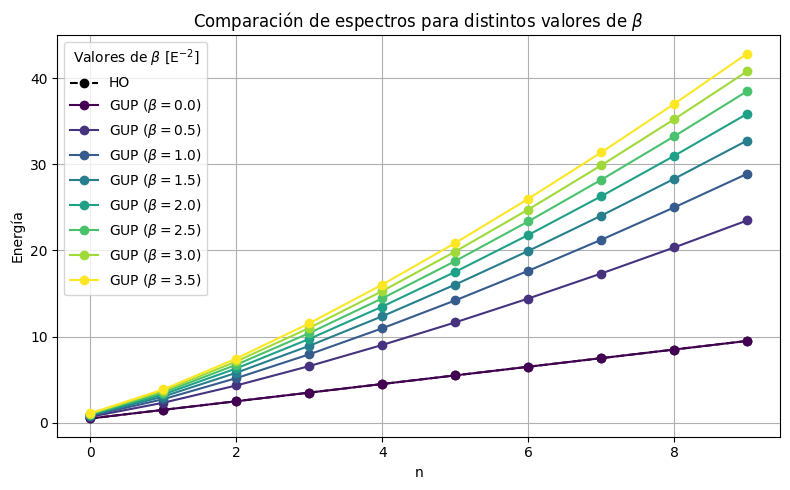

In [62]:
# Ajustar n_levels automáticamente
n_levels = len(n_vals)

plt.figure(figsize=(8, 5))

# HO como referencia
plt.plot(n_vals, evals0[:n_levels],
         'o--',
         color='black',
         label='HO')

# Colores viridis
colors = plt.cm.viridis(np.linspace(0, 1, len(betas_g)))

for beta_plot, c in zip(betas_g, colors):
    H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)
    evals_g, _ = np.linalg.eigh(H_g)

    plt.plot(n_vals, evals_g[:n_levels],
             marker='o',
             linestyle='-',
             color=c,
             label=fr'GUP ($\beta={beta_plot}$)')

plt.xlabel('n')
plt.ylabel('Energía')
plt.title('Comparación de espectros para distintos valores de $\\beta$')

plt.legend(title=r'Valores de $\beta$ [E$^{-2}$]')
plt.grid()
plt.tight_layout()

plt.show()

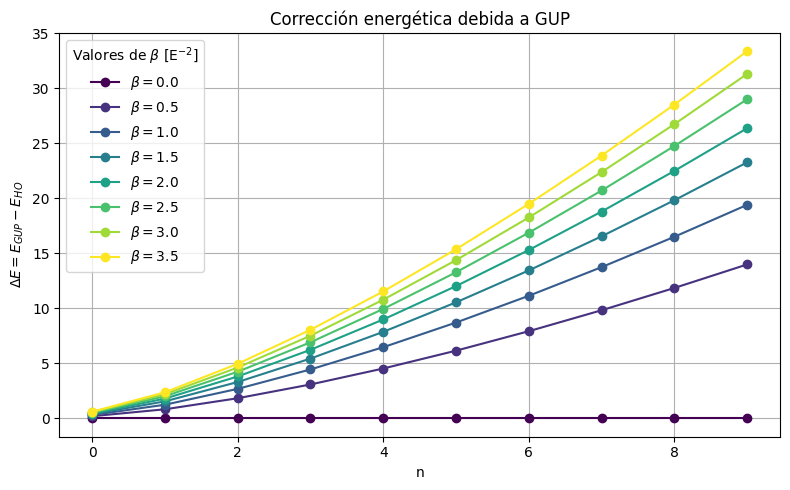

In [63]:
plt.figure(figsize=(8, 5))

# Colores tipo viridis
colors = plt.cm.viridis(np.linspace(0, 1, len(betas_g)))

for beta_plot, c in zip(betas_g, colors):
    H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)
    evals_g, _ = np.linalg.eigh(H_g)

    deltaE = evals_g[:n_levels] - evals0[:n_levels]

    plt.plot(n_vals, deltaE,
             marker='o',
             linestyle='-',
             color=c,
             label=fr'$\beta={beta_plot}$')

plt.xlabel('n')
plt.ylabel(r'$\Delta E = E_{GUP} - E_{HO}$')
plt.title('Corrección energética debida a GUP')

plt.legend(title=r'Valores de $\beta$ [E$^{-2}$]')
plt.grid()
plt.tight_layout()

plt.show()

## PERFIL ENERGÉTICO

In [64]:
def phi_n(x, n, m=1.0, w=1.0, hbar=1.0):
    xi = np.sqrt(float(m * w / hbar)) * x
    norm = (float(m * w / (math.pi * hbar)))**0.25 / math.sqrt((2.0**n) * math.factorial(n))
    return norm * eval_hermite(n, xi) * np.exp(-xi**2 / 2)

def reconstruct_wavefunction(x, coeffs, n_basis, m=1.0, w=1.0, hbar=1.0):
    psi = np.zeros_like(x, dtype=np.complex128)
    for k in range(n_basis):
        psi += coeffs[k] * phi_n(x, k, m, w, hbar)
    return psi

In [65]:
def plot_energy_spectrum_ho_gup(beta_plot, N, n_levels, m=1.0, w=1.0, hbar=1.0,
                                x_min=-2.5, x_max=2.5, nx=1000,
                                title_extra=""):

    H0 = hamiltonian_ho(N, m, w, hbar)
    H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)

    evals0, evecs0 = np.linalg.eigh(H0)
    evals_g, evecs_g = np.linalg.eigh(H_g)

    x = np.linspace(x_min, x_max, nx)

    Vx = 0.5 * m * w**2 * x**2
    gamma = 0.02 * beta_plot
    Veff = 0.5 * m * w**2 * x**2 + gamma * x**4

    colors = ['red', 'tab:orange', 'green', 'blueviolet', 'royalblue']

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    ax0, ax1 = axs

    # =========================
    # HO
    # =========================
    ax0.plot(x, Vx, color='blue', lw=1.5)
    ax0.set_title('Oscilador armónico cuántico', fontsize=16, fontweight='bold')
    ax0.set_xlabel(r'$x$')
    ax0.set_ylabel('Energía')

    for n in range(n_levels):
        E = evals0[n]

        ax0.hlines(E, x_min + 0.1, x_max - 0.1,
                   colors='royalblue', linestyles='dashed', linewidth=1)

        ax0.text(x_max + 0.05, E, rf'$n={n}$',
                 va='center', fontsize=12, color='navy')

        psi = reconstruct_wavefunction(x, evecs0[:, n], N, m, w, hbar).real
        psi_scaled = 0.35 * psi / np.max(np.abs(psi)) + E

        ax0.plot(x, psi_scaled, color=colors[n], lw=1.5)

    ax0.text(0.5, 0.92,
             r'$V(x)=\frac{1}{2}m\omega^2x^2$',
             transform=ax0.transAxes,
             ha='center',
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='royalblue'))

    ax0.set_xlim(x_min, x_max)
    ax0.grid(alpha=0.25)

    # =========================
    # GUP
    # =========================
    ax1.plot(x, Veff, color='blue', lw=1.5)
    ax1.set_title(rf'Oscilador con GUP ($\beta={beta_plot}$) {title_extra}',
                  fontsize=16, fontweight='bold')
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel('Energía')

    for n in range(n_levels):
        E = evals_g[n]

        ax1.hlines(E, x_min + 0.1, x_max - 0.1,
                   colors='royalblue', linestyles='dashed', linewidth=1)

        ax1.text(x_max + 0.05, E, rf'$n={n}$',
                 va='center', fontsize=12, color='navy')

        psi = reconstruct_wavefunction(x, evecs_g[:, n], N, m, w, hbar).real
        psi_scaled = 0.35 * psi / np.max(np.abs(psi)) + E

        ax1.plot(x, psi_scaled, color=colors[n], lw=1.5)

    ax1.text(0.5, 0.92,
             r'Efecto cualitativo de la GUP',
             transform=ax1.transAxes,
             ha='center',
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='royalblue'))

    ax1.set_xlim(x_min, x_max)
    
    # Misma escala vertical en HO y GUP
    ax1.set_xlim(x_min, x_max)

    # Misma escala vertical en ambos paneles
    # Misma escala vertical en HO y GUP
    ymax = evals0[n_levels - 1] + 1.0

    # Escalas independientes (correcto físicamente)
    ax0.set_ylim(0, evals0[n_levels - 1] + 1.0)
    ax1.set_ylim(0, evals_g[n_levels - 1] + 1.0)

    ax0.grid(alpha=0.25)
    ax1.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

In [66]:
def plot_density_ho_gup(beta_plot, N, n_levels, m=1.0, w=1.0, hbar=1.0,
                        x_min=-2.5, x_max=2.5, nx=1000,
                        title_extra=""):

    H0 = hamiltonian_ho(N, m, w, hbar)
    H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)

    evals0, evecs0 = np.linalg.eigh(H0)
    evals_g, evecs_g = np.linalg.eigh(H_g)

    x = np.linspace(x_min, x_max, nx)
    x_min = -2.5
    x_max = 2.5

    colors = ['red', 'tab:orange', 'green', 'blueviolet', 'royalblue']

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
    ax0, ax1 = axs

    # =========================
    # Densidades HO
    # =========================
    ax0.set_title(r'HO: densidades de probabilidad $|\psi_n(x)|^2$',
                  fontsize=15, fontweight='bold')

    for n in range(n_levels):
        psi = reconstruct_wavefunction(x, evecs0[:, n], N, m, w, hbar)
        prob = np.abs(psi)**2

        offset = (n_levels - 1 - n) * 1.4
        prob_scaled = 0.75 * prob / np.max(prob) + offset

        ax0.plot(x, prob_scaled, color=colors[n], lw=1.5)
        ax0.hlines(offset, x_min, x_max, color='gray', lw=0.8)
        ax0.text(x_min - 0.25, offset, rf'$n={n}$',
                 va='center', fontsize=12)

    ax0.set_xlim(x_min, x_max)
    ax0.set_xlabel(r'$x$')
    ax0.set_yticks([])
    ax0.grid(alpha=0.2)

    # =========================
    # Densidades GUP
    # =========================
    ax1.set_title(r'GUP: densidades de probabilidad $|\psi_n(x)|^2$',
                  fontsize=15, fontweight='bold')

    for n in range(n_levels):
        psi = reconstruct_wavefunction(x, evecs_g[:, n], N, m, w, hbar)
        prob = np.abs(psi)**2

        offset = (n_levels - 1 - n) * 1.4
        prob_scaled = 0.75 * prob / np.max(prob) + offset

        ax1.plot(x, prob_scaled, color=colors[n], lw=1.5)
        ax1.hlines(offset, x_min, x_max, color='gray', lw=0.8)
        ax1.text(x_min - 0.25, offset, rf'$n={n}$',
                 va='center', fontsize=12)

    ax1.set_xlim(x_min, x_max)
    ax1.set_xlabel(r'$x$')
    ax1.set_yticks([])
    ax1.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

### - BETAS PEQUEÑAS

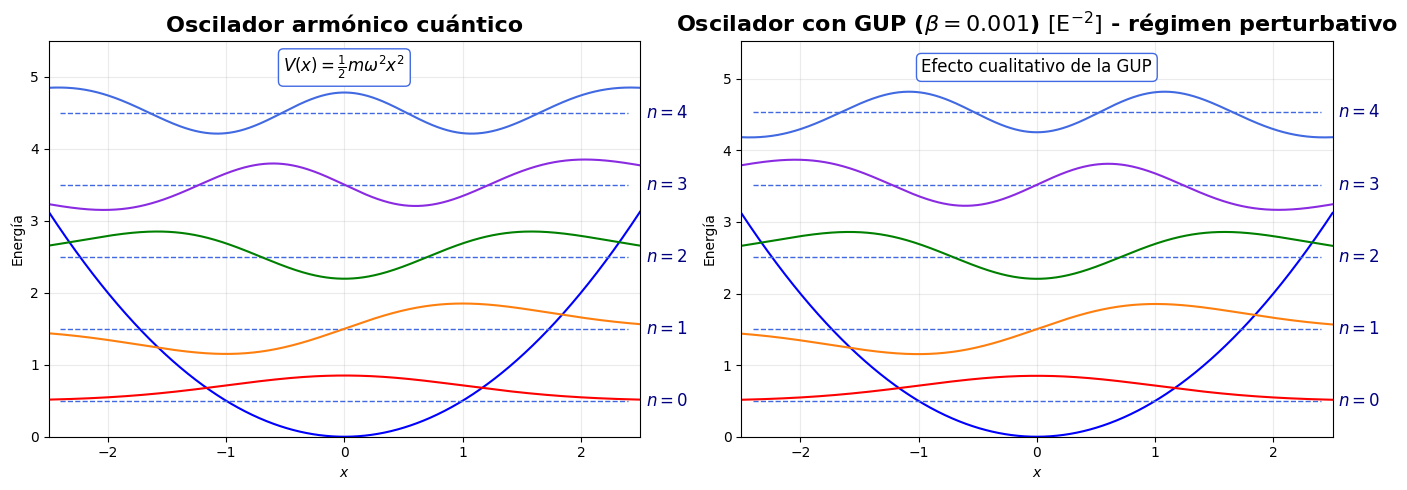

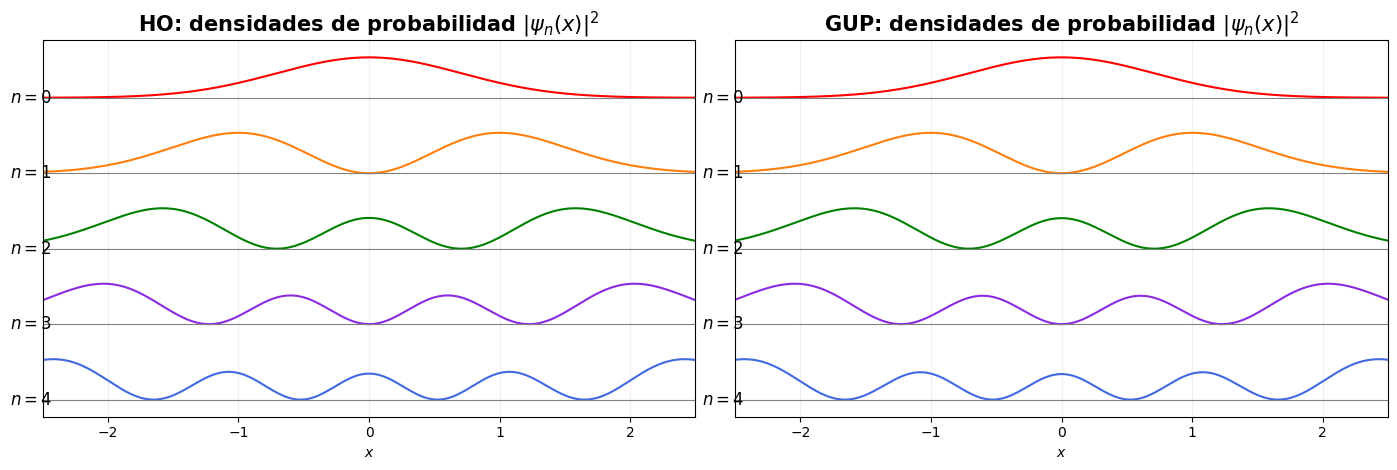

In [67]:
plot_energy_spectrum_ho_gup(
    beta_plot=0.001,
    N=N,
    n_levels=5,
    title_extra=r'$[\mathrm{E}^{-2}]$ - régimen perturbativo'
)

plot_density_ho_gup(
    beta_plot=0.001,
    N=N,
    n_levels=5,
    title_extra=r'$[\mathrm{E}^{-2}]$ - régimen perturbativo'
)

### - BETAS GRANDES

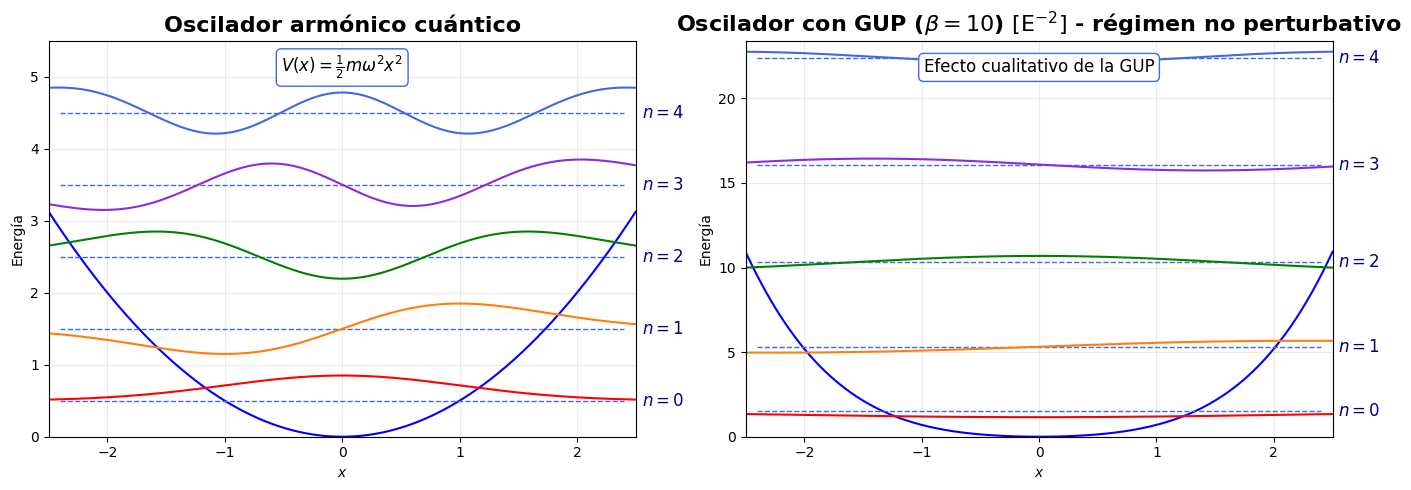

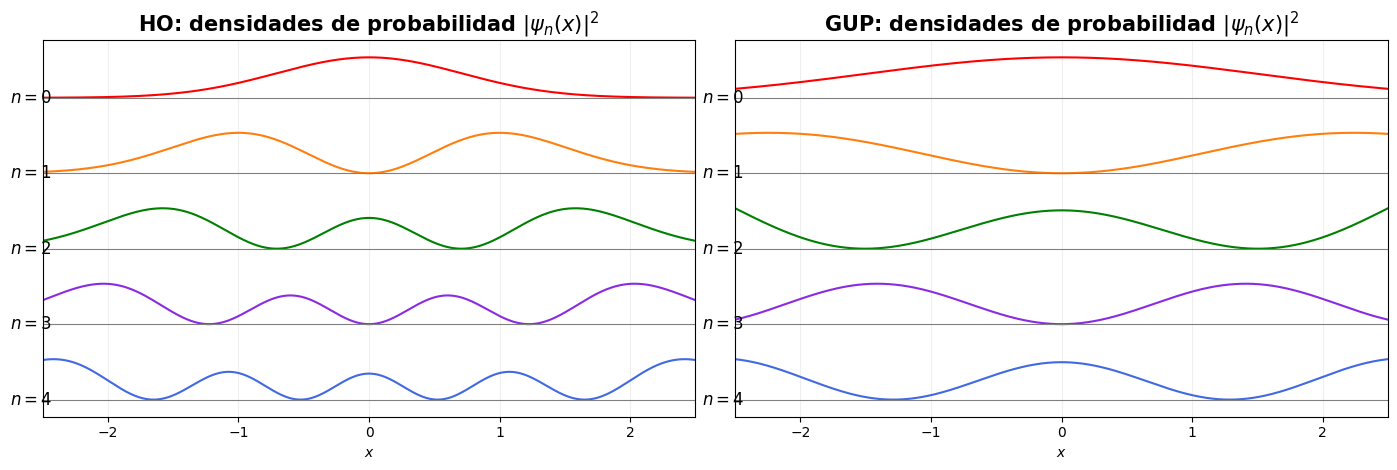

In [68]:
plot_energy_spectrum_ho_gup(
    beta_plot=10,
    N=N,
    n_levels=5,
    title_extra=r'$[\mathrm{E}^{-2}]$ - régimen no perturbativo'
)

plot_density_ho_gup(
    beta_plot=10,
    N=N,
    n_levels=5,
    title_extra=r'$[\mathrm{E}^{-2}]$ - régimen perturbativo'
)

## BOUNDS BETA.

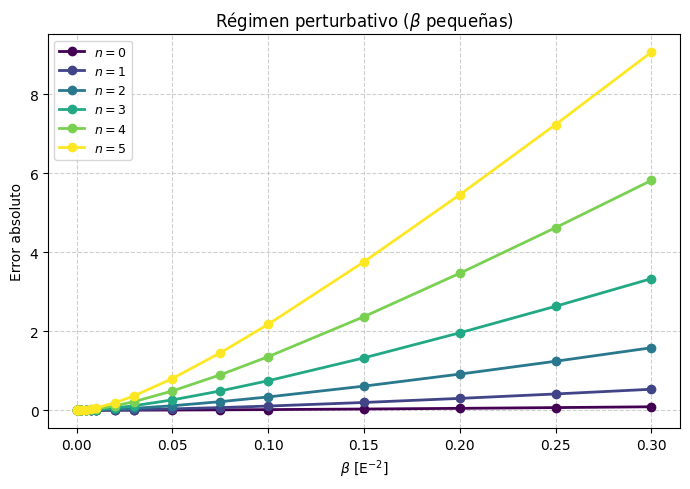

In [69]:
# ============================================
# GRÁFICA 1: Régimen perturbativo
# ============================================

niveles = [0, 1, 2, 3, 4, 5]
colors = plt.cm.viridis(np.linspace(0, 1, len(niveles)))

betas_peq_plot = np.array([
    0.0001, 0.0002, 0.0005, 0.001,
    0.002, 0.005, 0.0075, 0.01,
    0.02, 0.03, 0.05, 0.075, 0.1,
    0.15, 0.2, 0.25, 0.3
])

fig, ax = plt.subplots(figsize=(7,5))

for n, c in zip(niveles, colors):

    errors = []

    for beta in betas_peq_plot:

        H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)
        evals_g, _ = np.linalg.eigh(H_g)

        delta_num  = evals_g[n] - evals0[n]
        delta_pert = perturbative_shift(n, m, w, beta, hbar)

        error = abs(delta_num - delta_pert)
        errors.append(error)

    ax.plot(
        betas_peq_plot,
        errors,
        'o-',
        color=c,
        linewidth=2,
        label=fr'$n={n}$'
    )

ax.set_xlabel(r'$\beta$ [E$^{-2}$]')
ax.set_ylabel('Error absoluto')

ax.set_title(r'Régimen perturbativo ($\beta$ pequeñas)')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))

ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

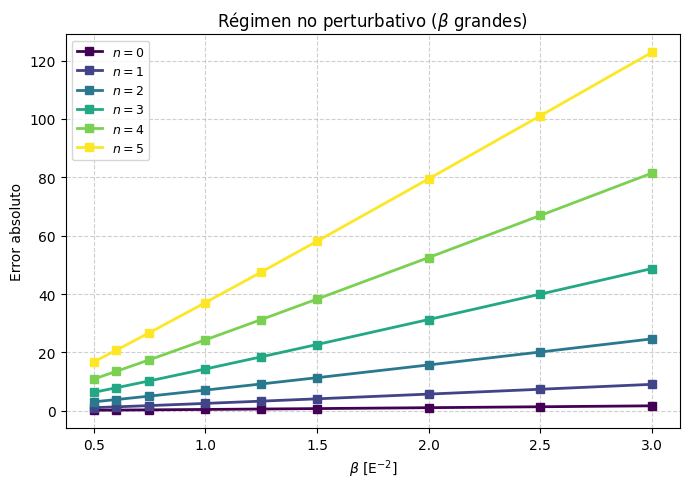

In [70]:
# ============================================
# GRÁFICA 2: Régimen no perturbativo
# ============================================

niveles = [0, 1, 2, 3, 4, 5]
colors = plt.cm.viridis(np.linspace(0, 1, len(niveles)))

betas_gran_plot = np.array([
    0.5, 0.6, 0.75, 1.0,
    1.25, 1.5, 2.0, 2.5, 3.0
])

fig, ax = plt.subplots(figsize=(7,5))

for n, c in zip(niveles, colors):

    errors = []

    for beta in betas_gran_plot:

        H_g, _, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)
        evals_g, _ = np.linalg.eigh(H_g)

        delta_num  = evals_g[n] - evals0[n]
        delta_pert = perturbative_shift(n, m, w, beta, hbar)

        error = abs(delta_num - delta_pert)
        errors.append(error)

    ax.plot(
        betas_gran_plot,
        errors,
        's-',
        color=c,
        linewidth=2,
        label=fr'$n={n}$'
    )

ax.set_xlabel(r'$\beta$ [E$^{-2}$]')
ax.set_ylabel('Error absoluto')

ax.set_title(r'Régimen no perturbativo ($\beta$ grandes)')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))

ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

## VQE

In [71]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import RealAmplitudes
from qiskit.circuit.library import real_amplitudes
from qiskit.quantum_info import Statevector
from qiskit_algorithms.optimizers import COBYLA
from qiskit.visualization import circuit_drawer
from IPython.display import display, Image

In [72]:
PAULI_1Q = {
    "I": np.array([[1, 0], [0, 1]], dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}

def kron_all(mats):
    out = mats[0]
    for M in mats[1:]:
        out = np.kron(out, M)
    return out

def precompute_paulis(nq):
    labels = ["".join(t) for t in itertools.product("IXYZ", repeat=nq)]
    paulis = []
    for lab in labels:
        P = kron_all([PAULI_1Q[ch] for ch in lab])
        paulis.append((lab, P))
    return paulis

def pauli_decompose(H, nq, tol=1e-12, paulis=None):
    dim = 2**nq
    assert H.shape == (dim, dim), "H debe ser (2^nq, 2^nq)."

    if paulis is None:
        paulis = precompute_paulis(nq)

    terms = []
    for lab, P in paulis:
        c = np.trace(P @ H) / dim
        if abs(c) > tol:
            c = float(np.real_if_close(c))
            terms.append((c, lab))
    return terms

def terms_to_sparsepauliop(terms):
    labels = [lab for (c, lab) in terms]
    coeffs = np.array([c for (c, lab) in terms], dtype=float)
    return SparsePauliOp(labels, coeffs=coeffs)

In [73]:
def run_vqe_statevector(operator, nq, reps=2, maxiter=200, seed=123): 
    ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")
    n_params = ansatz.num_parameters
    rng = np.random.default_rng(seed)

    def energy(theta):
        circ = ansatz.assign_parameters(theta, inplace=False)
        psi = Statevector.from_instruction(circ)
        return float(np.real(psi.expectation_value(operator)))

    x0 = rng.uniform(-0.1, 0.1, size=n_params)
    opt = COBYLA(maxiter=maxiter)
    res = opt.minimize(fun=energy, x0=x0)

    return float(res.fun), res.x

In [74]:
# Qubits y truncación
nq = 3
N = 2**nq

# Precalcular base de Pauli
paulis = precompute_paulis(nq)

In [75]:
# ============================================================
# Listas separadas
# ============================================================

E0_exact_p = []
EG_exact_p = []
E0_vqe_p   = []
EG_vqe_p   = []

E0_exact_g = []
EG_exact_g = []
E0_vqe_g   = []
EG_vqe_g   = []


# ============================================================
# BETAS PEQUEÑAS
# ============================================================

for beta in betas_p:
    # Hamiltonianos en base truncada
    H_GUP, H0, H1 = hamiltonian_gup_ho(N, m, w, beta, hbar)

    # Espectro exacto
    E0_exact = np.linalg.eigvalsh(H0)
    EG_exact = np.linalg.eigvalsh(H_GUP)

    E0_gs_exact = float(np.real(E0_exact[0]))
    EG_gs_exact = float(np.real(EG_exact[0]))

    # Descomposición a Pauli
    terms_H0 = pauli_decompose(H0, nq, paulis=paulis)
    terms_HG = pauli_decompose(H_GUP, nq, paulis=paulis)

    H0_op = terms_to_sparsepauliop(terms_H0)
    HG_op = terms_to_sparsepauliop(terms_HG)

    # VQE
    E0_vqe, _ = run_vqe_statevector(H0_op, nq, reps=2, maxiter=250, seed=1)
    EG_vqe, _ = run_vqe_statevector(HG_op, nq, reps=2, maxiter=250, seed=2)

    # Guardar resultados
    E0_exact_p.append(E0_gs_exact)
    EG_exact_p.append(EG_gs_exact)
    E0_vqe_p.append(E0_vqe)
    EG_vqe_p.append(EG_vqe)

    # Mostrar resultados por beta
    print(f"\nBeta pequeños = {beta}")
    print("-" * 50)
    print(f"H0 exacto     : {E0_gs_exact:.8f}")
    print(f"H0 VQE        : {E0_vqe:.8f}")
    print(f"HGUP exacto   : {EG_gs_exact:.8f}")
    print(f"HGUP VQE      : {EG_vqe:.8f}")
    print(f"Delta exacto  : {EG_gs_exact - E0_gs_exact:.8f}")
    print(f"Delta VQE     : {EG_vqe - E0_vqe:.8f}")

# ============================================================
# BETAS GRANDES
# ============================================================

for beta in betas_g:
    # Hamiltonianos en base truncada
    H_GUP, H0, H1 = hamiltonian_gup_ho(N, m, w, beta, hbar)

    # Espectro exacto
    E0_exact = np.linalg.eigvalsh(H0)
    EG_exact = np.linalg.eigvalsh(H_GUP)

    E0_gs_exact = float(np.real(E0_exact[0]))
    EG_gs_exact = float(np.real(EG_exact[0]))

    # Descomposición a Pauli
    terms_H0 = pauli_decompose(H0, nq, paulis=paulis)
    terms_HG = pauli_decompose(H_GUP, nq, paulis=paulis)

    H0_op = terms_to_sparsepauliop(terms_H0)
    HG_op = terms_to_sparsepauliop(terms_HG)

    # VQE
    E0_vqe, _ = run_vqe_statevector(H0_op, nq, reps=2, maxiter=250, seed=1)
    EG_vqe, _ = run_vqe_statevector(HG_op, nq, reps=2, maxiter=250, seed=2)

    # Guardar resultados
    E0_exact_g.append(E0_gs_exact)
    EG_exact_g.append(EG_gs_exact)
    E0_vqe_g.append(E0_vqe)
    EG_vqe_g.append(EG_vqe)

    # Mostrar resultados por beta
    print(f"\nBeta grandes = {beta}")
    print("-" * 50)
    print(f"H0 exacto     : {E0_gs_exact:.8f}")
    print(f"H0 VQE        : {E0_vqe:.8f}")
    print(f"HGUP exacto   : {EG_gs_exact:.8f}")
    print(f"HGUP VQE      : {EG_vqe:.8f}")
    print(f"Delta exacto  : {EG_gs_exact - E0_gs_exact:.8f}")
    print(f"Delta VQE     : {EG_vqe - E0_vqe:.8f}")

C:\Users\angel\AppData\Local\Temp\ipykernel_32940\2359357329.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")



Beta pequeños = 0.0
--------------------------------------------------
H0 exacto     : 0.50000000
H0 VQE        : 0.50000007
HGUP exacto   : 0.50000000
HGUP VQE      : 0.50000003
Delta exacto  : 0.00000000
Delta VQE     : -0.00000004

Beta pequeños = 0.0001
--------------------------------------------------
H0 exacto     : 0.50000000
H0 VQE        : 0.50000007
HGUP exacto   : 0.50007497
HGUP VQE      : 0.50007499
Delta exacto  : 0.00007497
Delta VQE     : 0.00007492

Beta pequeños = 0.0005
--------------------------------------------------
H0 exacto     : 0.50000000
H0 VQE        : 0.50000007
HGUP exacto   : 0.50037435
HGUP VQE      : 0.50037436
Delta exacto  : 0.00037435
Delta VQE     : 0.00037429

Beta pequeños = 0.001
--------------------------------------------------
H0 exacto     : 0.50000000
H0 VQE        : 0.50000007
HGUP exacto   : 0.50074740
HGUP VQE      : 0.50074740
Delta exacto  : 0.00074740
Delta VQE     : 0.00074734

Beta pequeños = 0.005
--------------------------------

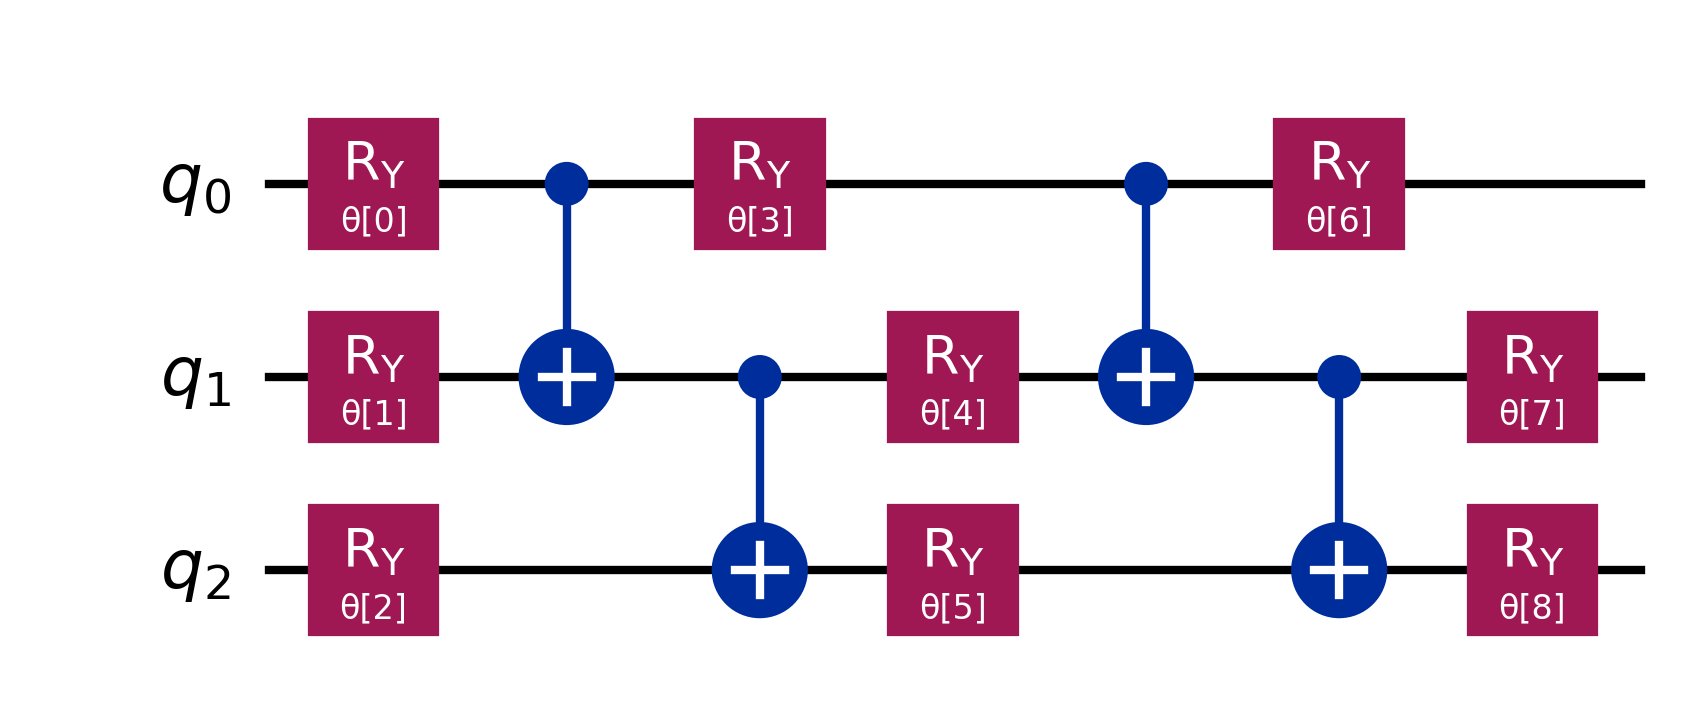

In [76]:
nq = 3
reps = 2

ansatz = real_amplitudes(
    num_qubits=nq,
    reps=reps,
    entanglement="linear"
)

fig = circuit_drawer(ansatz, output="mpl", fold=20)

nombre = "circuito_vqe_ansatz.png"
fig.savefig(nombre, bbox_inches="tight", dpi=300)

display(Image(filename=nombre))

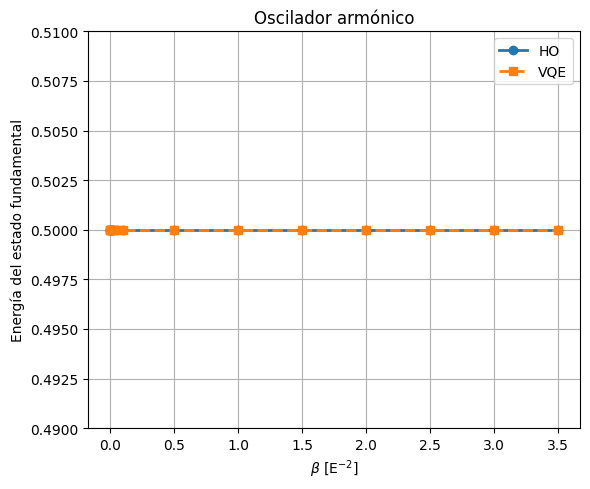

In [77]:
# ============================================
# GRÁFICA 1: Oscilador armónico (HO)
# ============================================

fig, ax = plt.subplots(figsize=(6,5))

# Unimos beta pequeñas y grandes
betas_ho = np.concatenate((betas_p, betas_g[1:]))

# HO no depende de beta
ho_exact = E0_exact_p[0]
ho_vqe   = E0_vqe_p[0]

E0_exact_all = np.full_like(betas_ho, ho_exact, dtype=float)
E0_vqe_all   = np.full_like(betas_ho, ho_vqe, dtype=float)

ax.plot(betas_ho, E0_exact_all, 'o-', linewidth=2, label='HO')
ax.plot(betas_ho, E0_vqe_all, 's--', linewidth=2, label='VQE')

ax.set_xlabel(r'$\beta$ [E$^{-2}$]')
ax.set_ylabel('Energía del estado fundamental')
ax.set_title('Oscilador armónico')

ax.ticklabel_format(style='plain', axis='y')
ax.set_ylim(0.49, 0.51)

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

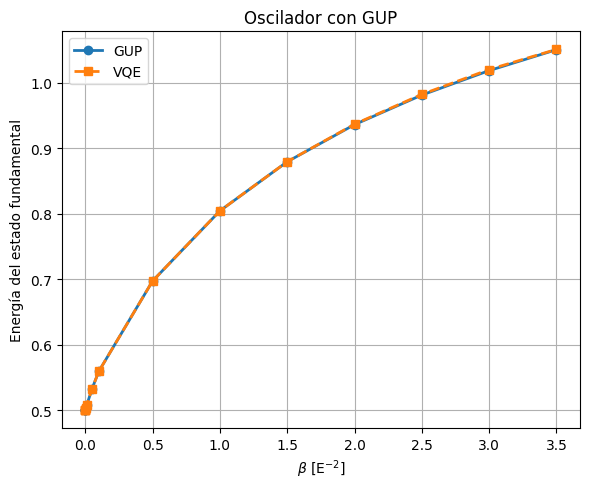

In [78]:
# ============================================
# GRÁFICA 2: Oscilador con GUP
# ============================================

fig, ax = plt.subplots(figsize=(6,5))

betas_gup = np.concatenate((betas_p, betas_g[1:]))

EG_exact_all = np.concatenate((EG_exact_p, EG_exact_g[1:]))
EG_vqe_all   = np.concatenate((EG_vqe_p, EG_vqe_g[1:]))

ax.plot(betas_gup, EG_exact_all, 'o-', linewidth=2, label='GUP')
ax.plot(betas_gup, EG_vqe_all, 's--', linewidth=2, label='VQE')

ax.set_xlabel(r'$\beta$ [E$^{-2}$]')
ax.set_ylabel('Energía del estado fundamental')
ax.set_title('Oscilador con GUP')

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [79]:
# HO
rel_err_H0_p = np.abs(np.array(E0_vqe_p) - np.array(E0_exact_p)) / np.abs(E0_exact_p)
rel_err_H0_g = np.abs(np.array(E0_vqe_g) - np.array(E0_exact_g)) / np.abs(E0_exact_g)

# GUP
rel_err_HG_p = np.abs(np.array(EG_vqe_p) - np.array(EG_exact_p)) / np.abs(EG_exact_p)
rel_err_HG_g = np.abs(np.array(EG_vqe_g) - np.array(EG_exact_g)) / np.abs(EG_exact_g)

## ITERACIONES

In [80]:
def run_vqe_statevector_with_history(operator, nq, reps=2, maxiter=200, seed=123):
    ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")
    n_params = ansatz.num_parameters
    rng = np.random.default_rng(seed)

    history = []

    def energy(theta):
        circ = ansatz.assign_parameters(theta, inplace=False)
        psi = Statevector.from_instruction(circ)
        val = float(np.real(psi.expectation_value(operator)))
        return val

    def callback(xk):
        history.append(energy(xk))

    x0 = rng.uniform(-0.1, 0.1, size=n_params)

    res = minimize(
        energy,
        x0,
        method="COBYLA",
        callback=callback,
        options={"maxiter": maxiter}
    )

    if len(history) == 0 or abs(history[-1] - float(res.fun)) > 1e-12:
        history.append(float(res.fun))

    return float(res.fun), res.x, history

In [81]:
# Elegir beta para el caso GUP
beta_plot = 1.0

# Hamiltonianos
H_GUP, H0, _ = hamiltonian_gup_ho(N, m, w, beta_plot, hbar)

# Energías exactas
E0_exact = np.linalg.eigvalsh(H0)
EG_exact = np.linalg.eigvalsh(H_GUP)

E0_gs_exact = float(np.real(E0_exact[0]))
EG_gs_exact = float(np.real(EG_exact[0]))

# Operadores de Pauli
terms_H0 = pauli_decompose(H0, nq, paulis=paulis)
terms_HG = pauli_decompose(H_GUP, nq, paulis=paulis)

H0_op = terms_to_sparsepauliop(terms_H0)
HG_op = terms_to_sparsepauliop(terms_HG)

# VQE con historia
E0_vqe, theta0_opt, hist0 = run_vqe_statevector_with_history(
    H0_op, nq, reps=2, maxiter=250, seed=1
)

EG_vqe, thetaG_opt, histG = run_vqe_statevector_with_history(
    HG_op, nq, reps=2, maxiter=250, seed=2
)

print("HO exacto :", E0_gs_exact)
print("HO VQE    :", E0_vqe)
print("GUP exacto:", EG_gs_exact)
print("GUP VQE   :", EG_vqe)

print("len(hist0) =", len(hist0))
print("len(histG) =", len(histG))

C:\Users\angel\AppData\Local\Temp\ipykernel_32940\738080226.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")


HO exacto : 0.5000000000000001
HO VQE    : 0.5000000653528125
GUP exacto: 0.8045207366908593
GUP VQE   : 0.8046378138769876
len(hist0) = 107
len(histG) = 198


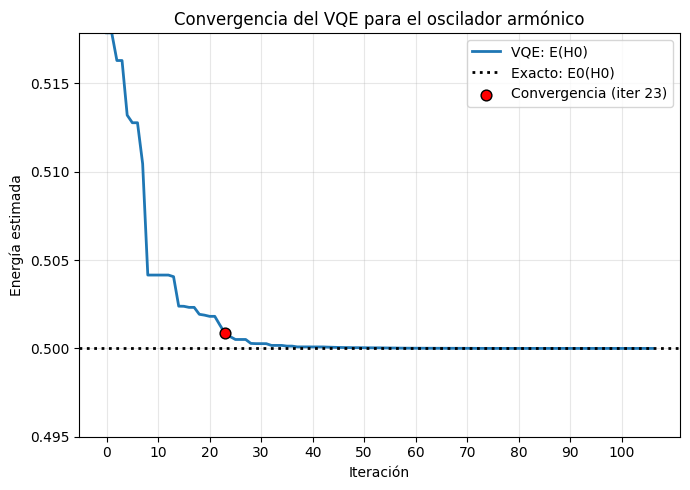

In [82]:
plt.figure(figsize=(7,5))

# función para encontrar iteración
def first_iteration_within_tolerance(history, exact_value, tol=1e-3):
    history = np.array(history, dtype=float)
    diff = np.abs(history - exact_value)
    idx = np.where(diff < tol)[0]
    return int(idx[0]) if len(idx) > 0 else None

tol = 1e-3 

# curva VQE
plt.plot(hist0,
         linewidth=2,
         label="VQE: E(H0)",
         markevery=4)

# línea exacta
plt.axhline(E0_gs_exact,
            linestyle=":",
            color="black",
            linewidth=2,
            label="Exacto: E0(H0)")

# punto de convergencia
it_conv = first_iteration_within_tolerance(hist0, E0_gs_exact, tol=tol)

if it_conv is not None:
    plt.scatter(it_conv, hist0[it_conv],
                color="red",
                edgecolor="black",
                s=60,
                zorder=5,
                label=f"Convergencia (iter {it_conv})")

# ejes
plt.xlabel("Iteración")
plt.ylabel("Energía estimada")
plt.title("Convergencia del VQE para el oscilador armónico")

plt.xticks(np.arange(0, len(hist0)+1, 10))

# zoom fino (mejorado)
plt.ylim(E0_gs_exact - 0.005, max(hist0[:10]))

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_32940\738080226.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")


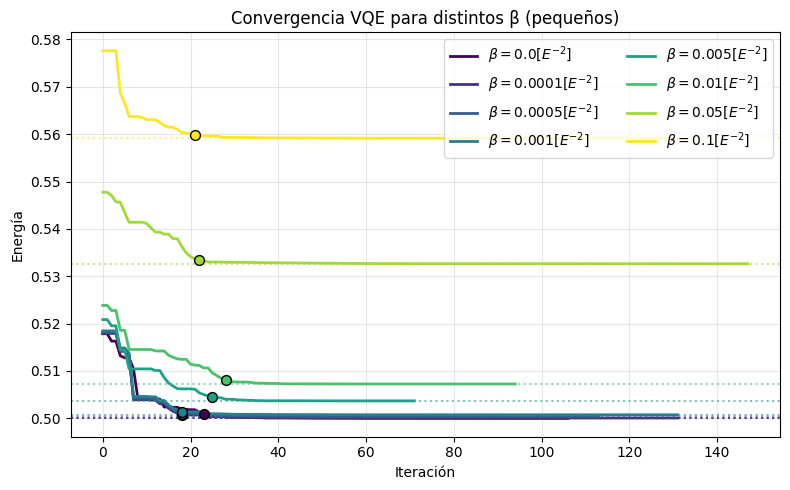

In [83]:
plt.figure(figsize=(8,5))

colors = plt.cm.viridis(np.linspace(0, 1, len(betas_p)))

# función de convergencia
def first_iteration_within_tolerance(history, exact_value, tol=1e-3):
    history = np.array(history, dtype=float)
    diff = np.abs(history - exact_value)
    idx = np.where(diff < tol)[0]
    return int(idx[0]) if len(idx) > 0 else None

tol = 1e-3 

for beta, c in zip(betas_p, colors):

    H_GUP, _, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)

    # energía exacta
    EG_exact = np.linalg.eigvalsh(H_GUP)
    EG_gs_exact = float(np.real(EG_exact[0]))

    terms = pauli_decompose(H_GUP, nq, paulis=paulis)
    op = terms_to_sparsepauliop(terms)

    _, _, histG = run_vqe_statevector_with_history(
        op, nq, reps=2, maxiter=200, seed=1
    )

    # curva
    plt.plot(histG, color=c, linewidth=2,
             label=fr'$\beta={beta} [E^{{-2}}]$')

    # línea exacta
    plt.axhline(EG_gs_exact,
                linestyle=":",
                color=c,
                alpha=0.6)

    # punto de convergencia
    it_conv = first_iteration_within_tolerance(histG, EG_gs_exact, tol=tol)

    if it_conv is not None:
        plt.scatter(it_conv, histG[it_conv],
                    color=c,
                    edgecolor='black',
                    s=50,
                    zorder=5)

plt.xlabel("Iteración")
plt.ylabel("Energía")
plt.title("Convergencia VQE para distintos β (pequeños)")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [84]:
def first_iteration_within_tolerance(history, exact_value, tol=1e-3):
    history = np.array(history, dtype=float)
    diff = np.abs(history - exact_value)
    indices = np.where(diff < tol)[0]
    if len(indices) == 0:
        return None
    return int(indices[0])

tol = 1e-3
iteraciones_pequenas = {}

for beta in betas_p:
    H_GUP, _, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)

    EG_exact = np.linalg.eigvalsh(H_GUP)
    EG_gs_exact = float(np.real(EG_exact[0]))

    terms = pauli_decompose(H_GUP, nq, paulis=paulis)
    op = terms_to_sparsepauliop(terms)

    _, _, histG = run_vqe_statevector_with_history(
        op, nq, reps=2, maxiter=200, seed=1
    )

    it_conv = first_iteration_within_tolerance(histG, EG_gs_exact, tol=tol)
    iteraciones_pequenas[beta] = it_conv

print("Iteración de convergencia para betas pequeñas:")
for beta, it_conv in iteraciones_pequenas.items():
    print(f"beta = {beta}: {it_conv}")

C:\Users\angel\AppData\Local\Temp\ipykernel_32940\738080226.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")


Iteración de convergencia para betas pequeñas:
beta = 0.0: 23
beta = 0.0001: 18
beta = 0.0005: 18
beta = 0.001: 18
beta = 0.005: 25
beta = 0.01: 28
beta = 0.05: 22
beta = 0.1: 21


C:\Users\angel\AppData\Local\Temp\ipykernel_32940\738080226.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")


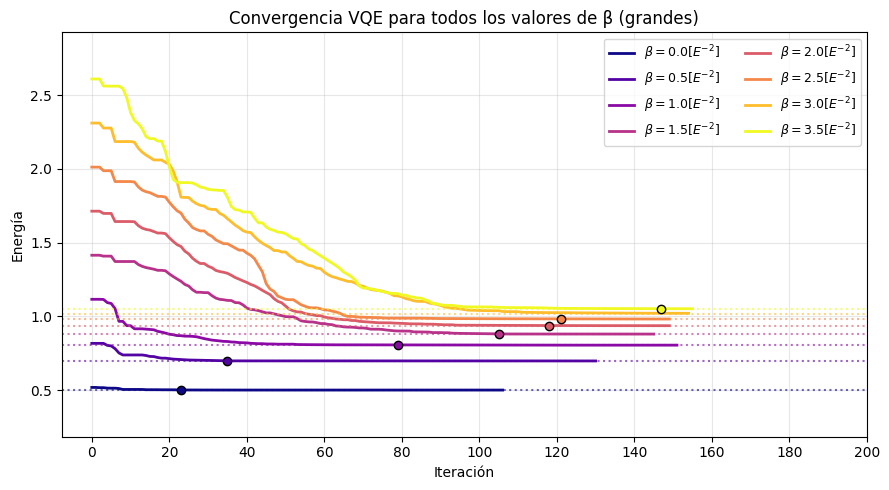

In [85]:
plt.figure(figsize=(9,5))

colors = plt.cm.plasma(np.linspace(0, 1, len(betas_g)))

all_values = []

# función para encontrar la iteración
def first_iteration_within_tolerance(history, exact_value, tol=1e-3):
    history = np.array(history, dtype=float)
    diff = np.abs(history - exact_value)
    idx = np.where(diff < tol)[0]
    return int(idx[0]) if len(idx) > 0 else None

tol = 1e-3  

for beta, c in zip(betas_g, colors):

    H_GUP, _, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)

    EG_exact = np.linalg.eigvalsh(H_GUP)
    EG_gs_exact = float(np.real(EG_exact[0]))

    terms = pauli_decompose(H_GUP, nq, paulis=paulis)
    op = terms_to_sparsepauliop(terms)

    _, _, histG = run_vqe_statevector_with_history(
        op, nq, reps=2, maxiter=200, seed=1
    )

    # guardar valores
    all_values.extend(histG)
    all_values.append(EG_gs_exact)

    # curva
    plt.plot(histG, color=c, linewidth=2, label=fr'$\beta={beta} [E^{{-2}}]$')

    # línea exacta
    plt.axhline(EG_gs_exact, linestyle=":", color=c, alpha=0.6)

    # punto de convergencia
    it_conv = first_iteration_within_tolerance(histG, EG_gs_exact, tol=tol)

    if it_conv is not None:
        plt.scatter(it_conv, histG[it_conv],
                    color=c,
                    edgecolor='black',
                    zorder=5)

# ajustar eje Y
ymin = min(all_values)
ymax = max(all_values)
margen = 0.15 * (ymax - ymin)

plt.ylim(ymin - margen, ymax + margen)

plt.xlabel("Iteración")
plt.ylabel("Energía")
plt.title("Convergencia VQE para todos los valores de β (grandes)")

plt.xticks(np.arange(0, 201, 20))
plt.grid(alpha=0.3)

plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [86]:
tol = 1e-3
iteraciones_grandes = {}

for beta in betas_g:
    H_GUP, _, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)

    EG_exact = np.linalg.eigvalsh(H_GUP)
    EG_gs_exact = float(np.real(EG_exact[0]))

    terms = pauli_decompose(H_GUP, nq, paulis=paulis)
    op = terms_to_sparsepauliop(terms)

    _, _, histG = run_vqe_statevector_with_history(
        op, nq, reps=2, maxiter=200, seed=1
    )

    it_conv = first_iteration_within_tolerance(histG, EG_gs_exact, tol=tol)
    iteraciones_grandes[beta] = it_conv

print("Iteración de convergencia para betas grandes:")
for beta, it_conv in iteraciones_grandes.items():
    print(f"beta = {beta}: {it_conv}")

C:\Users\angel\AppData\Local\Temp\ipykernel_32940\738080226.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=nq, reps=reps, entanglement="linear")


Iteración de convergencia para betas grandes:
beta = 0.0: 23
beta = 0.5: 35
beta = 1.0: 79
beta = 1.5: 105
beta = 2.0: 118
beta = 2.5: 121
beta = 3.0: None
beta = 3.5: 147


## PRODUCTO DE INCERTIDUMBRES

In [87]:
def annihilation_operator(N):
    a = np.zeros((N, N), dtype=complex)
    for n in range(1, N):
        a[n-1, n] = np.sqrt(n)
    return a

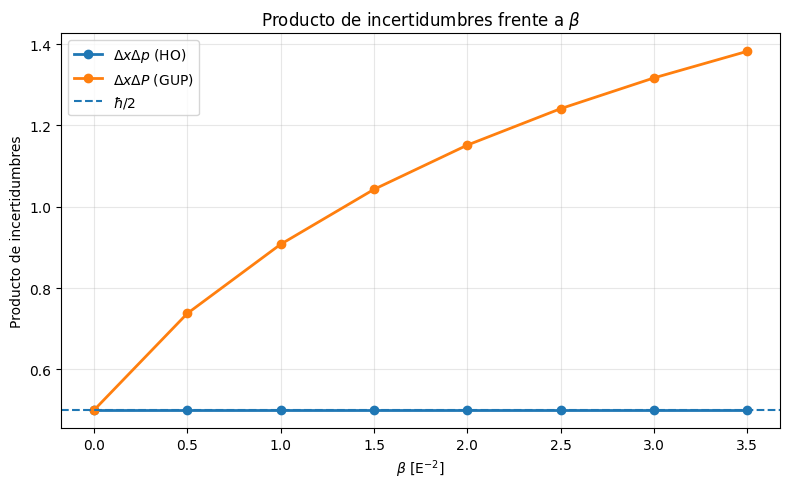

In [88]:
# ============================================================
# Operadores x y p del oscilador armónico en base truncada
# ============================================================

def x_operator(N, m=1.0, w=1.0, hbar=1.0):
    a = annihilation_operator(N)
    adag = a.conj().T
    return np.sqrt(hbar / (2 * m * w)) * (a + adag)

def p_operator(N, m=1.0, w=1.0, hbar=1.0):
    a = annihilation_operator(N)
    adag = a.conj().T
    return 1j * np.sqrt(hbar * m * w / 2) * (adag - a)

# ============================================================
# Valor esperado e incertidumbre
# ============================================================

def expectation(psi, A):
    psi = np.asarray(psi, dtype=complex).reshape(-1)
    return np.real(np.vdot(psi, A @ psi))

def uncertainty(psi, A):
    A2 = A @ A
    mean_A = expectation(psi, A)
    mean_A2 = expectation(psi, A2)
    var = mean_A2 - mean_A**2
    var = max(var, 0.0)  # evitar pequeños errores numéricos negativos
    return np.sqrt(var)

# ============================================================
# Cálculo del producto Delta x Delta p
# ============================================================

# Elige la lista de betas que quieras:
betas_plot = betas_g   # o betas_p, o una lista manual

DxDp_HO = []
DxDP_GUP = []

X = x_operator(N, m, w, hbar)
p = p_operator(N, m, w, hbar)

for beta in betas_plot:
    H_GUP, H0, _ = hamiltonian_gup_ho(N, m, w, beta, hbar)

    evals0, evecs0 = np.linalg.eigh(H0)
    evalsG, evecsG = np.linalg.eigh(H_GUP)

    psi0 = evecs0[:, 0]
    psiG = evecsG[:, 0]

    # HO estándar
    Dx0 = uncertainty(psi0, X)
    Dp0 = uncertainty(psi0, p)
    DxDp_HO.append(Dx0 * Dp0)

    # Momento físico GUP
    P_GUP = p @ (np.eye(N) + beta * (p @ p))

    DxG = uncertainty(psiG, X)
    DPG = uncertainty(psiG, P_GUP)
    DxDP_GUP.append(DxG * DPG)

DxDp_HO = np.array(DxDp_HO)
DxDP_GUP = np.array(DxDP_GUP)

# ============================================================
# Gráfica
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(betas_plot, DxDp_HO,
         'o-', linewidth=2,
         label=r'$\Delta x \Delta p$ (HO)')

plt.plot(betas_plot, DxDP_GUP,
         'o-', linewidth=2,
         label=r'$\Delta x \Delta P$ (GUP)')

plt.axhline(hbar/2,
            linestyle='--',
            label=r'$\hbar/2$')

plt.xlabel(r'$\beta$ [E$^{-2}$]')
plt.ylabel(r'Producto de incertidumbres')
plt.title(r'Producto de incertidumbres frente a $\beta$')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()